In diesem Notebook vergleiche ich LC Model MetabMaps von LR8 vs N2V + LR8

In [1]:
#for i in {1..8}; do cp "$i/Orig/Glx_amp_map.mnc" "/ceph/mri.meduniwien.ac.at/departments/radiology/mrsbrain/public/hfish/Deuterium_Denosing/notebooks/MetabMaps/Glx_amp_map_$i.mnc"; done

In [ ]:
# import nibabel as nib
# import numpy as np

# metabolite = 'Lac'
# data_list = []

# for i in range(1, 9):
#     filepath = f"MetabMaps/{metabolite}_amp_map_{i}.mnc"
#     img = nib.load(filepath)
#     data = img.get_fdata()  # ladet als NumPy-Array (float64)
#     data_list.append(data)

# # Stack entlang einer neuen letzten Achse
# stacked = np.stack(data_list, axis=-1)
# print("Shape:", stacked.shape)

# np.save(f'MetabMaps/{metabolite}.npy', stacked)

# import nibabel as nib
# import numpy as np

# data_list = []

# for i in range(1, 9):
#     filepath = f"MetabMaps/{metabolite}_sd_map_{i}.mnc"
#     img = nib.load(filepath)
#     data = img.get_fdata()  # ladet als NumPy-Array (float64)
#     data_list.append(data)

# # Stack entlang einer neuen letzten Achse
# stacked = np.stack(data_list, axis=-1)
# print("Shape:", stacked.shape)

# np.save(f'MetabMaps/{metabolite}_sd.npy', stacked)


Shape: (21, 22, 22, 8)
Shape: (21, 22, 22, 8)


# Wasser

/tmp/ipykernel_2036271/2295968875.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.95, 1])


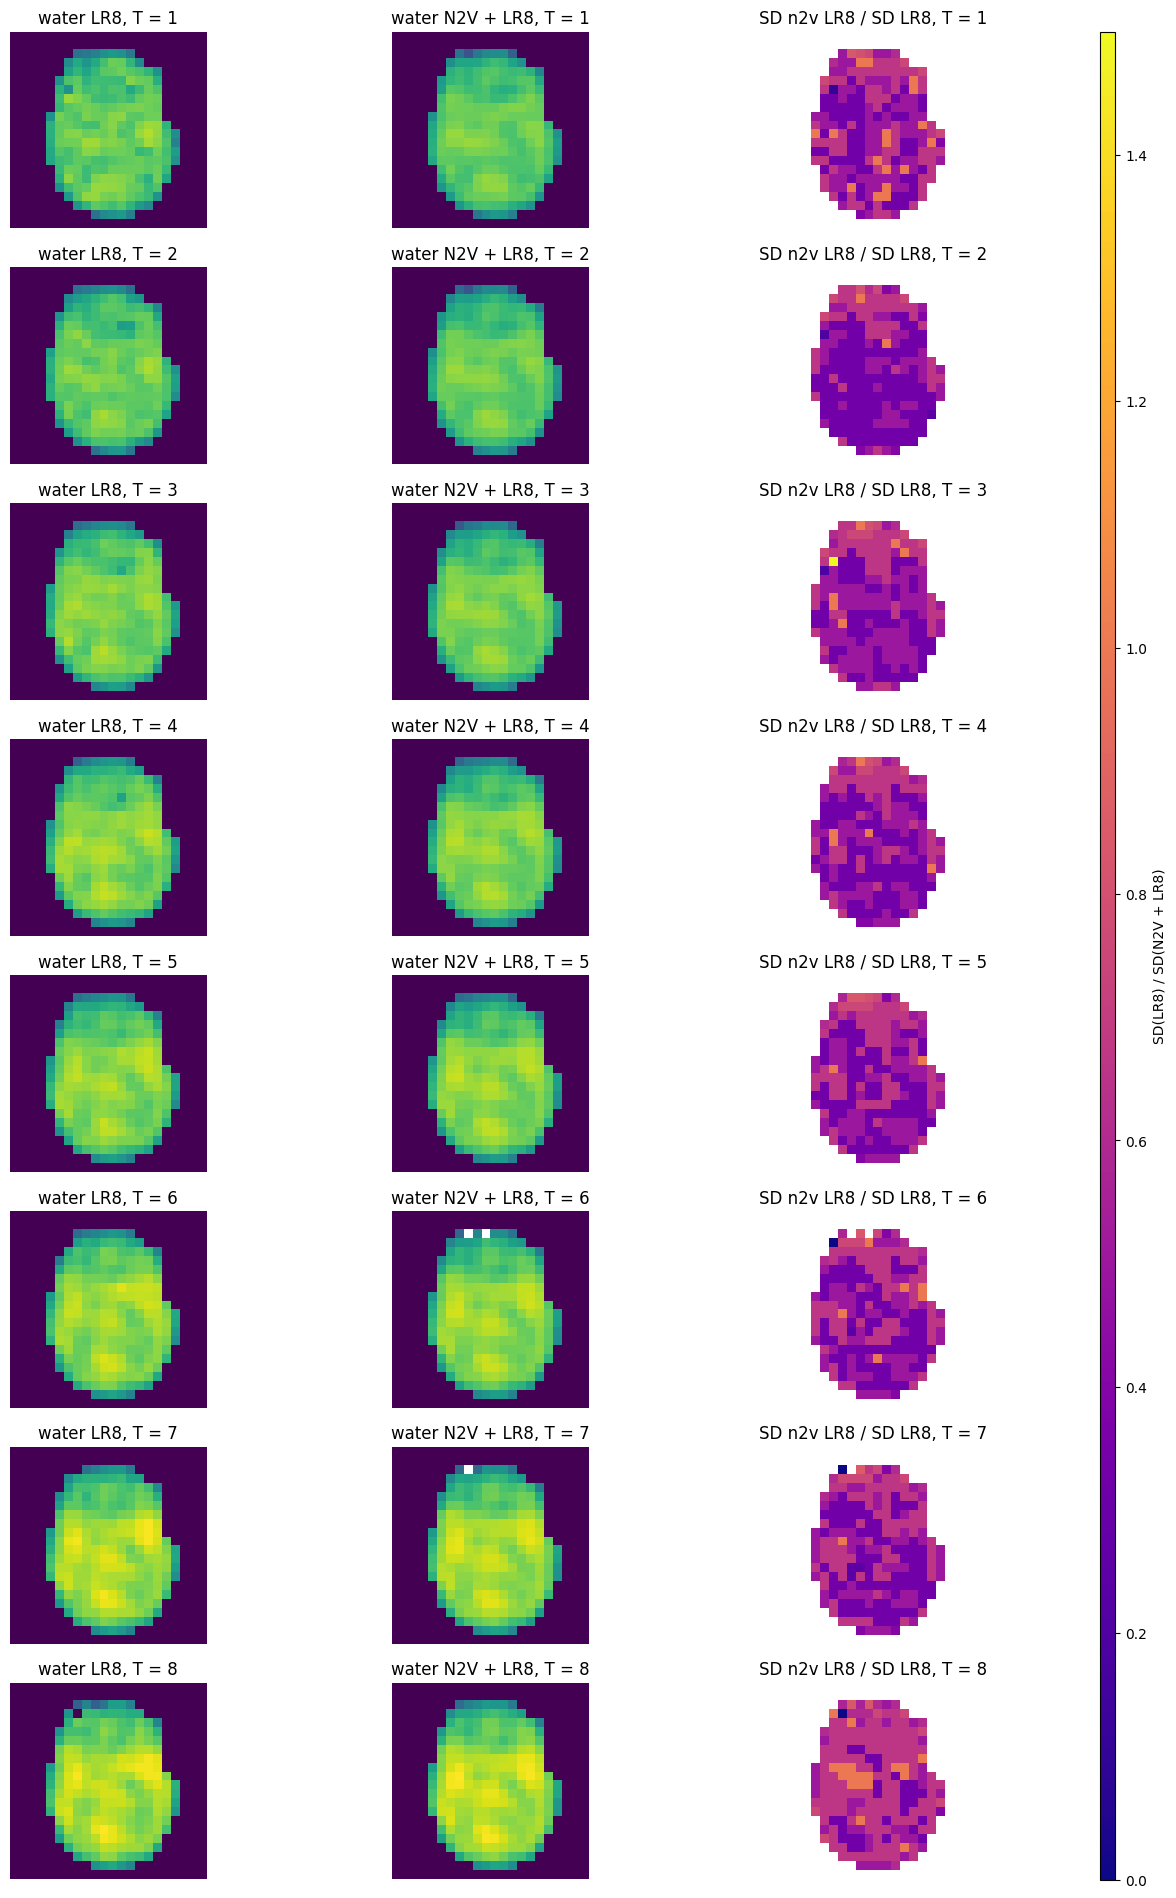

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Daten laden
water         = np.load("MetabMaps/water_LR8.npy")            # (21, 22, 22, 8)
water_n2v     = np.load("MetabMaps/water_n2v_LR8.npy")        # (21, 22, 22, 8)
water_sd      = np.load("MetabMaps/water_LR8_sd.npy")         # (21, 22, 22, 8)
water_n2v_sd  = np.load("MetabMaps/water_n2v_LR8_sd.npy")     # (21, 22, 22, 8)

# Slice bei z = 10
z = 10
water_slice        = water[z, :, :, :]
water_n2v_slice    = water_n2v[z, :, :, :]
water_sd_slice     = water_sd[z, :, :, :]
water_n2v_sd_slice = water_n2v_sd[z, :, :, :]

# SD-Quotient berechnen
with np.errstate(divide='ignore', invalid='ignore'):
    sd_ratio_slice = np.where(water_sd_slice != 0, water_n2v_sd_slice/water_sd_slice, np.nan)

# Gemeinsame min/max-Werte für LR8 und N2V
vmin0, vmax0 = np.nanmin(water_slice),        np.nanmax(water_slice)
vmin1, vmax1 = np.nanmin(water_n2v_slice),    np.nanmax(water_n2v_slice)

# Feste Farbskala für SD-Quotient
vmin2, vmax2 = 0, 1.5

# Layout: 3 Spalten + Colorbar rechts
fig = plt.figure(figsize=(15, 24))
gs = gridspec.GridSpec(8, 4, width_ratios=[1, 1, 1, 0.05], wspace=0.3)

ims2 = []  # Für SD-Quotient

for i in range(8):
    ax0 = plt.subplot(gs[i, 0])
    ax1 = plt.subplot(gs[i, 1])
    ax2 = plt.subplot(gs[i, 2])

    # LR8
    ax0.imshow(water_slice[..., i], cmap='viridis', vmin=vmin0, vmax=vmax0)
    ax0.set_title(f'water LR8, T = {i+1}')
    ax0.axis('off')

    # N2V + LR8
    ax1.imshow(water_n2v_slice[..., i], cmap='viridis', vmin=vmin1, vmax=vmax1)
    ax1.set_title(f'water N2V + LR8, T = {i+1}')
    ax1.axis('off')

    # SD-Quotient
    im2 = ax2.imshow(sd_ratio_slice[..., i], cmap='plasma', vmin=vmin2, vmax=vmax2)
    ax2.set_title(f'SD n2v LR8 / SD LR8, T = {i+1}')
    ax2.axis('off')
    ims2.append(im2)

# Colorbar für SD-Quotient
cax2 = fig.add_subplot(gs[:, 3])
cb2 = fig.colorbar(ims2[0], cax=cax2)
cb2.set_label('SD(LR8) / SD(N2V + LR8)')

plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()




# Glc

/tmp/ipykernel_2036271/2466776654.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.95, 1])


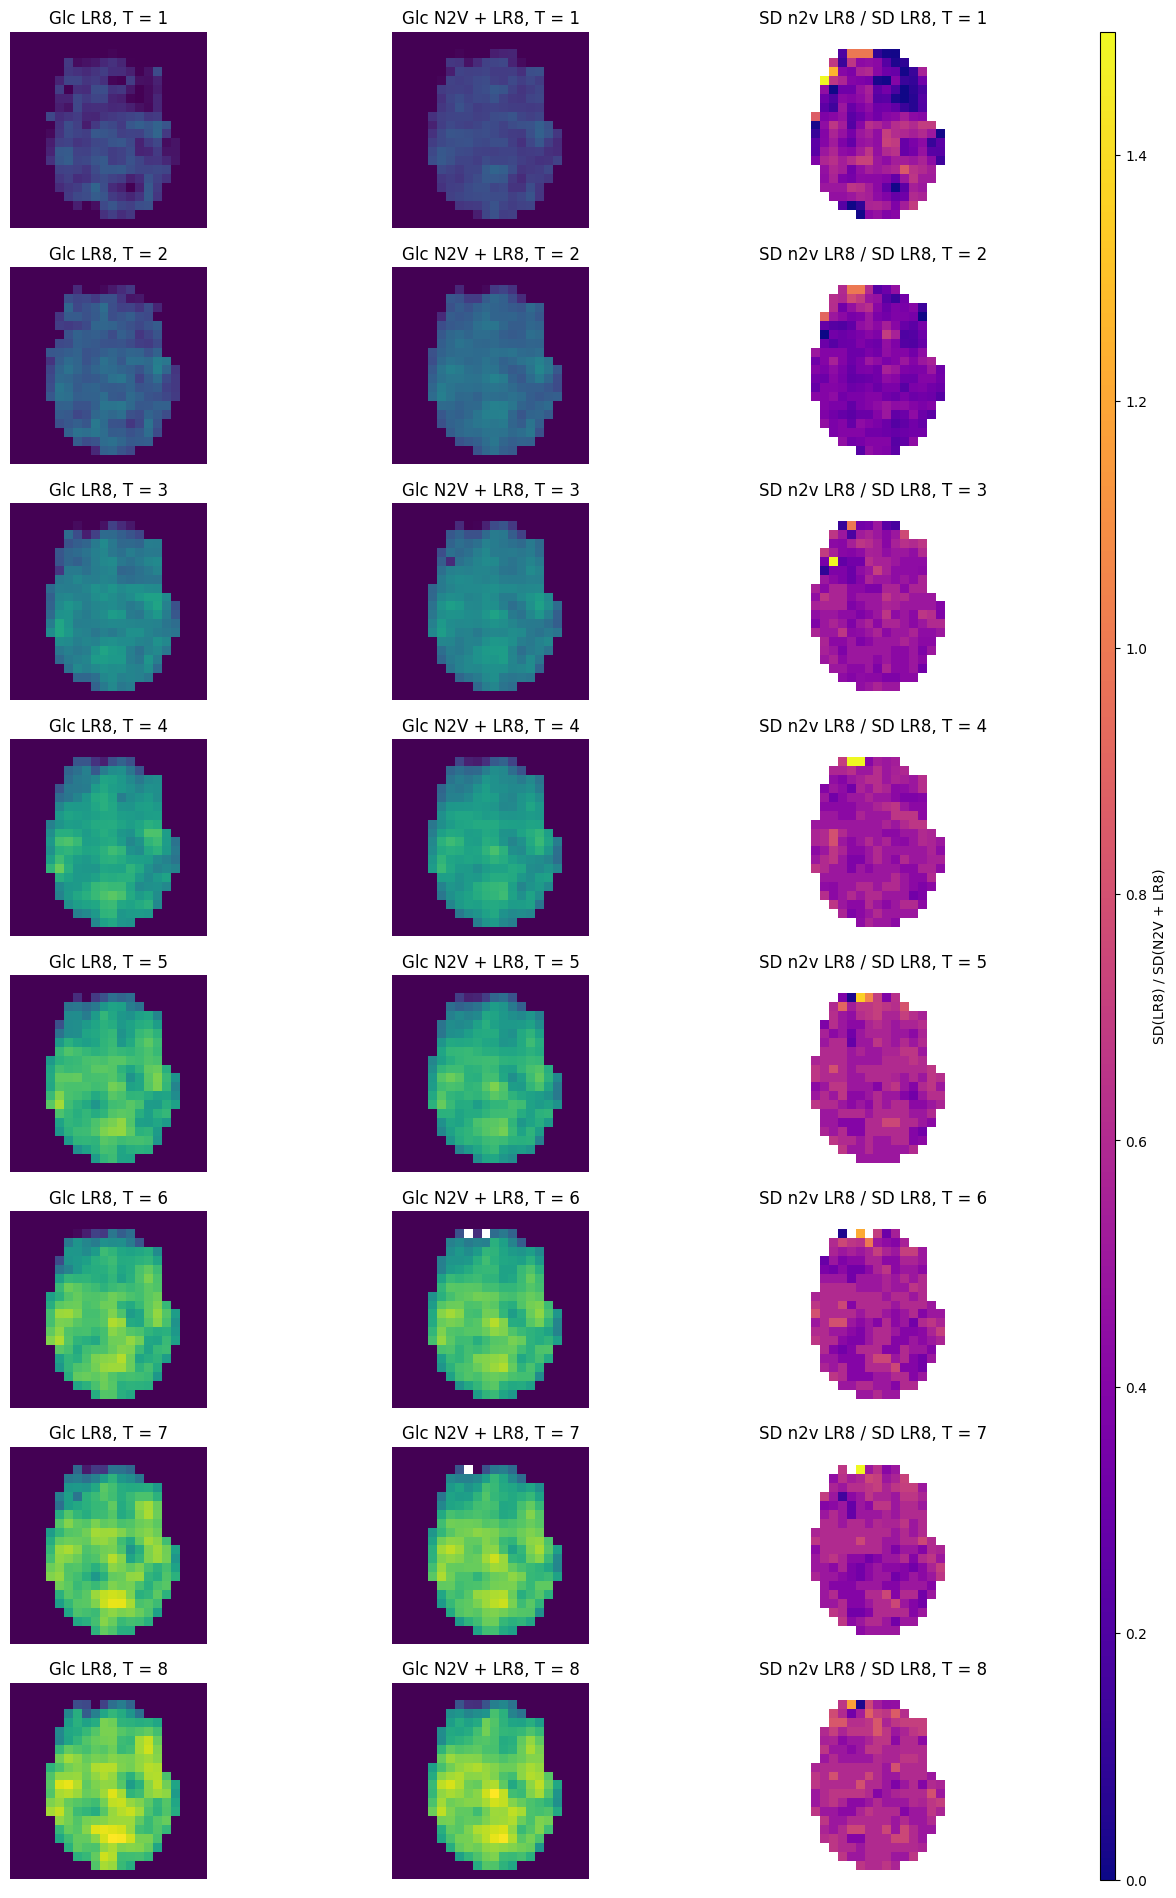

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

metabolite = 'Glc'

# Daten laden
water         = np.load(f"MetabMaps/{metabolite}_LR8.npy")            # (21, 22, 22, 8)
water_n2v     = np.load(f"MetabMaps/{metabolite}_n2v_LR8.npy")        # (21, 22, 22, 8)
water_sd      = np.load(f"MetabMaps/{metabolite}_LR8_sd.npy")         # (21, 22, 22, 8)
water_n2v_sd  = np.load(f"MetabMaps/{metabolite}_n2v_LR8_sd.npy")     # (21, 22, 22, 8)

# Slice bei z = 10
z = 10
water_slice        = water[z, :, :, :]
water_n2v_slice    = water_n2v[z, :, :, :]
water_sd_slice     = water_sd[z, :, :, :]
water_n2v_sd_slice = water_n2v_sd[z, :, :, :]

# SD-Quotient berechnen
with np.errstate(divide='ignore', invalid='ignore'):
    sd_ratio_slice = np.where(water_sd_slice != 0, water_n2v_sd_slice/water_sd_slice, np.nan)

# Gemeinsame min/max-Werte für LR8 und N2V
vmin0, vmax0 = np.nanmin(water_slice),        np.nanmax(water_slice)
vmin1, vmax1 = np.nanmin(water_n2v_slice),    np.nanmax(water_n2v_slice)

# Feste Farbskala für SD-Quotient
vmin2, vmax2 = 0, 1.5

# Layout: 3 Spalten + Colorbar rechts
fig = plt.figure(figsize=(15, 24))
gs = gridspec.GridSpec(8, 4, width_ratios=[1, 1, 1, 0.05], wspace=0.3)

ims2 = []  # Für SD-Quotient

for i in range(8):
    ax0 = plt.subplot(gs[i, 0])
    ax1 = plt.subplot(gs[i, 1])
    ax2 = plt.subplot(gs[i, 2])

    # LR8
    ax0.imshow(water_slice[..., i], cmap='viridis', vmin=vmin0, vmax=vmax0)
    ax0.set_title(f'{metabolite} LR8, T = {i+1}')
    ax0.axis('off')

    # N2V + LR8
    ax1.imshow(water_n2v_slice[..., i], cmap='viridis', vmin=vmin1, vmax=vmax1)
    ax1.set_title(f'{metabolite} N2V + LR8, T = {i+1}')
    ax1.axis('off')

    # SD-Quotient
    im2 = ax2.imshow(sd_ratio_slice[..., i], cmap='plasma', vmin=vmin2, vmax=vmax2)
    ax2.set_title(f'SD n2v LR8 / SD LR8, T = {i+1}')
    ax2.axis('off')
    ims2.append(im2)

# Colorbar für SD-Quotient
cax2 = fig.add_subplot(gs[:, 3])
cb2 = fig.colorbar(ims2[0], cax=cax2)
cb2.set_label('SD(LR8) / SD(N2V + LR8)')

plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()

# Glx

/tmp/ipykernel_2036271/1175760175.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.95, 1])


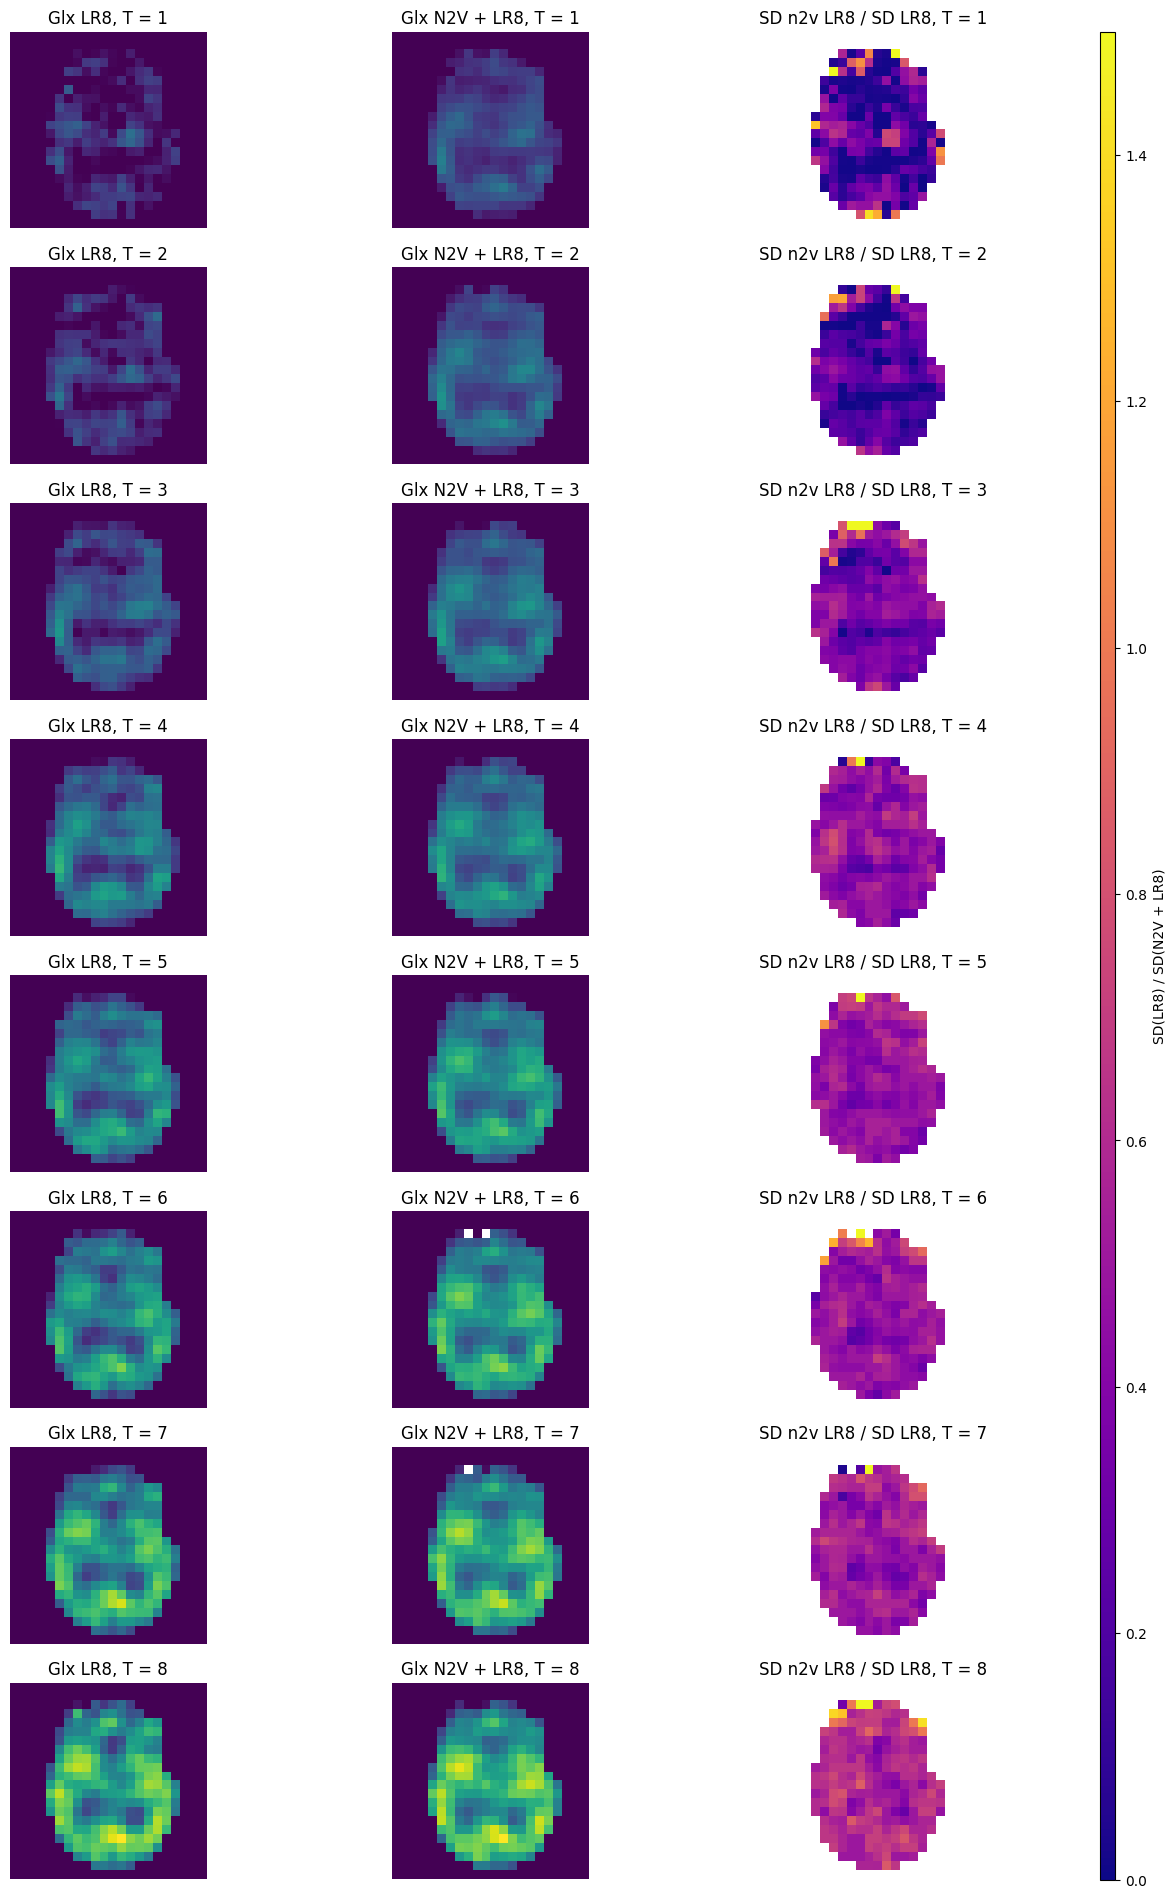

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

metabolite = 'Glx'

# Daten laden
water         = np.load(f"MetabMaps/{metabolite}_LR8.npy")            # (21, 22, 22, 8)
water_n2v     = np.load(f"MetabMaps/{metabolite}_n2v_LR8.npy")        # (21, 22, 22, 8)
water_sd      = np.load(f"MetabMaps/{metabolite}_LR8_sd.npy")         # (21, 22, 22, 8)
water_n2v_sd  = np.load(f"MetabMaps/{metabolite}_n2v_LR8_sd.npy")     # (21, 22, 22, 8)

# Slice bei z = 10
z = 10
water_slice        = water[z, :, :, :]
water_n2v_slice    = water_n2v[z, :, :, :]
water_sd_slice     = water_sd[z, :, :, :]
water_n2v_sd_slice = water_n2v_sd[z, :, :, :]

# SD-Quotient berechnen
with np.errstate(divide='ignore', invalid='ignore'):
    sd_ratio_slice = np.where(water_sd_slice != 0, water_n2v_sd_slice/water_sd_slice, np.nan)

# Gemeinsame min/max-Werte für LR8 und N2V
vmin0, vmax0 = np.nanmin(water_slice),        np.nanmax(water_slice)
vmin1, vmax1 = np.nanmin(water_n2v_slice),    np.nanmax(water_n2v_slice)

# Feste Farbskala für SD-Quotient
vmin2, vmax2 = 0, 1.5

# Layout: 3 Spalten + Colorbar rechts
fig = plt.figure(figsize=(15, 24))
gs = gridspec.GridSpec(8, 4, width_ratios=[1, 1, 1, 0.05], wspace=0.3)

ims2 = []  # Für SD-Quotient

for i in range(8):
    ax0 = plt.subplot(gs[i, 0])
    ax1 = plt.subplot(gs[i, 1])
    ax2 = plt.subplot(gs[i, 2])

    # LR8
    ax0.imshow(water_slice[..., i], cmap='viridis', vmin=vmin0, vmax=vmax0)
    ax0.set_title(f'{metabolite} LR8, T = {i+1}')
    ax0.axis('off')

    # N2V + LR8
    ax1.imshow(water_n2v_slice[..., i], cmap='viridis', vmin=vmin1, vmax=vmax1)
    ax1.set_title(f'{metabolite} N2V + LR8, T = {i+1}')
    ax1.axis('off')

    # SD-Quotient
    im2 = ax2.imshow(sd_ratio_slice[..., i], cmap='plasma', vmin=vmin2, vmax=vmax2)
    ax2.set_title(f'SD n2v LR8 / SD LR8, T = {i+1}')
    ax2.axis('off')
    ims2.append(im2)

# Colorbar für SD-Quotient
cax2 = fig.add_subplot(gs[:, 3])
cb2 = fig.colorbar(ims2[0], cax=cax2)
cb2.set_label('SD(LR8) / SD(N2V + LR8)')

plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()

# Lac

/tmp/ipykernel_2036271/3160768103.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.95, 1])


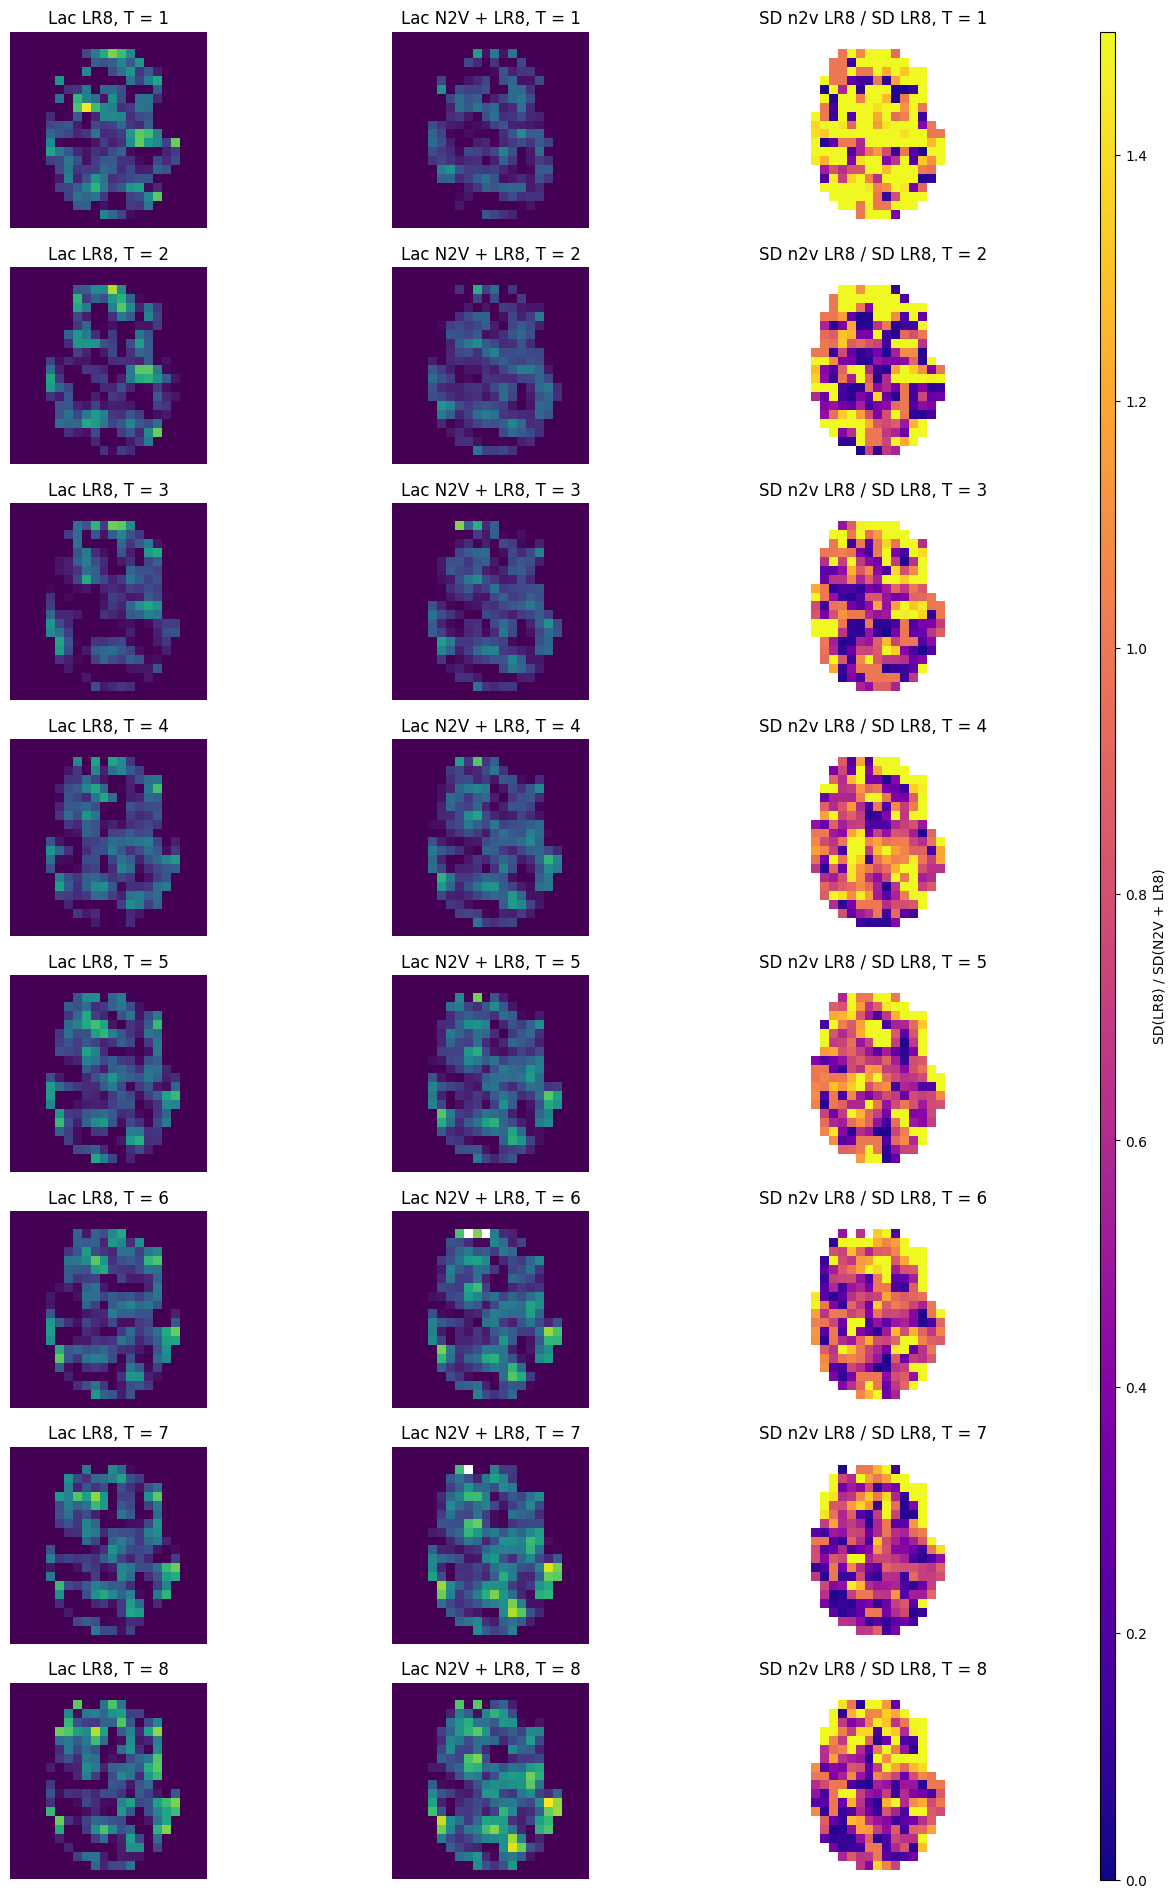

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

metabolite = 'Lac'

# Daten laden
water         = np.load(f"MetabMaps/{metabolite}_LR8.npy")            # (21, 22, 22, 8)
water_n2v     = np.load(f"MetabMaps/{metabolite}_n2v_LR8.npy")        # (21, 22, 22, 8)
water_sd      = np.load(f"MetabMaps/{metabolite}_LR8_sd.npy")         # (21, 22, 22, 8)
water_n2v_sd  = np.load(f"MetabMaps/{metabolite}_n2v_LR8_sd.npy")     # (21, 22, 22, 8)

# Slice bei z = 10
z = 10
water_slice        = water[z, :, :, :]
water_n2v_slice    = water_n2v[z, :, :, :]
water_sd_slice     = water_sd[z, :, :, :]
water_n2v_sd_slice = water_n2v_sd[z, :, :, :]

# SD-Quotient berechnen
with np.errstate(divide='ignore', invalid='ignore'):
    sd_ratio_slice = np.where(water_sd_slice != 0, water_n2v_sd_slice/water_sd_slice, np.nan)

# Gemeinsame min/max-Werte für LR8 und N2V
vmin0, vmax0 = np.nanmin(water_slice),        np.nanmax(water_slice)
vmin1, vmax1 = np.nanmin(water_n2v_slice),    np.nanmax(water_n2v_slice)

# Feste Farbskala für SD-Quotient
vmin2, vmax2 = 0, 1.5

# Layout: 3 Spalten + Colorbar rechts
fig = plt.figure(figsize=(15, 24))
gs = gridspec.GridSpec(8, 4, width_ratios=[1, 1, 1, 0.05], wspace=0.3)

ims2 = []  # Für SD-Quotient

for i in range(8):
    ax0 = plt.subplot(gs[i, 0])
    ax1 = plt.subplot(gs[i, 1])
    ax2 = plt.subplot(gs[i, 2])

    # LR8
    ax0.imshow(water_slice[..., i], cmap='viridis', vmin=vmin0, vmax=vmax0)
    ax0.set_title(f'{metabolite} LR8, T = {i+1}')
    ax0.axis('off')

    # N2V + LR8
    ax1.imshow(water_n2v_slice[..., i], cmap='viridis', vmin=vmin1, vmax=vmax1)
    ax1.set_title(f'{metabolite} N2V + LR8, T = {i+1}')
    ax1.axis('off')

    # SD-Quotient
    im2 = ax2.imshow(sd_ratio_slice[..., i], cmap='plasma', vmin=vmin2, vmax=vmax2)
    ax2.set_title(f'SD n2v LR8 / SD LR8, T = {i+1}')
    ax2.axis('off')
    ims2.append(im2)

# Colorbar für SD-Quotient
cax2 = fig.add_subplot(gs[:, 3])
cb2 = fig.colorbar(ims2[0], cax=cax2)
cb2.set_label('SD(LR8) / SD(N2V + LR8)')

plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()